In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/github-repository-metadata-with-5-stars/repo_metadata.json


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("pelmers/github-repository-metadata-with-5-stars")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/github-repository-metadata-with-5-stars


In [3]:
df = pd.read_json(f"{path}/repo_metadata.json")

In [4]:
df.head()

,owner,name,stars,forks,watchers,isFork,isArchived,languages,languageCount,topics,...,primaryLanguage,createdAt,pushedAt,defaultBranchCommitCount,license,assignableUserCount,codeOfConduct,forkingAllowed,nameWithOwner,parent
0,freeCodeCamp,freeCodeCamp,426893,41377,8588,False,False,"[{'name': 'TypeScript', 'size': 2843131}, {'na...",6,"[{'name': 'learn-to-code', 'stars': 480}, {'na...",...,TypeScript,2014-12-24T17:49:19Z,2025-08-31T09:33:14Z,39026.0,"BSD 3-Clause ""New"" or ""Revised"" License",42,Other,True,freeCodeCamp/freeCodeCamp,NaN
1,codecrafters-io,build-your-own-x,415801,38976,6247,False,False,"[{'name': 'Markdown', 'size': 46108}]",1,"[{'name': 'programming', 'stars': 1849}, {'nam...",...,Markdown,2018-05-09T12:03:18Z,2025-08-29T00:08:20Z,580.0,None,5,None,True,codecrafters-io/build-your-own-x,NaN
2,sindresorhus,awesome,396445,31414,8011,False,False,[],0,"[{'name': 'awesome', 'stars': 85421}, {'name':...",...,None,2014-07-11T13:42:37Z,2025-07-18T18:37:33Z,1173.0,Creative Commons Zero v1.0 Universal,1,Contributor Covenant,True,sindresorhus/awesome,NaN
3,EbookFoundation,free-programming-books,366964,64025,9879,False,False,"[{'name': 'Python', 'size': 26631}, {'name': '...",2,"[{'name': 'education', 'stars': 684}, {'name':...",...,Python,2013-10-11T06:50:37Z,2025-08-25T21:06:44Z,9535.0,Creative Commons Attribution 4.0 International,17,Contributor Covenant,True,EbookFoundation/free-programming-books,NaN
4,public-apis,public-apis,363505,38166,4360,False,False,"[{'name': 'Python', 'size': 40479}, {'name': '...",2,"[{'name': 'api', 'stars': 105389}, {'name': 'p...",...,Python,2016-03-20T23:49:42Z,2025-05-20T15:56:34Z,4536.0,MIT License,12,None,True,public-apis/public-apis,NaN


In [5]:
# Filtrant repositoris que siguin forks, només ens interessen els originals
df = df[df["isFork"] == False]
# Seleccionant les columnes que ens interessen
df_interest = df[["nameWithOwner","primaryLanguage","diskUsageKb", "stars", "forks", "watchers", "pullRequests", "issues", "license", "topics", "createdAt"]]

In [6]:
print(f"Rows: {df_interest.shape[0]}, Columns: {df_interest.shape[1]}")

Rows: 4247611, Columns: 11


In [7]:
df_interest.head()

,nameWithOwner,primaryLanguage,diskUsageKb,stars,forks,watchers,pullRequests,issues,license,topics,createdAt
0,freeCodeCamp/freeCodeCamp,TypeScript,512574,426893,41377,8588,41267,19849,"BSD 3-Clause ""New"" or ""Revised"" License","[{'name': 'learn-to-code', 'stars': 480}, {'na...",2014-12-24T17:49:19Z
1,codecrafters-io/build-your-own-x,Markdown,1066,415801,38976,6247,485,827,None,"[{'name': 'programming', 'stars': 1849}, {'nam...",2018-05-09T12:03:18Z
2,sindresorhus/awesome,None,1500,396445,31414,8011,2189,354,Creative Commons Zero v1.0 Universal,"[{'name': 'awesome', 'stars': 85421}, {'name':...",2014-07-11T13:42:37Z
3,EbookFoundation/free-programming-books,Python,19611,366964,64025,9879,10495,1184,Creative Commons Attribution 4.0 International,"[{'name': 'education', 'stars': 684}, {'name':...",2013-10-11T06:50:37Z
4,public-apis/public-apis,Python,4771,363505,38166,4360,3571,718,MIT License,"[{'name': 'api', 'stars': 105389}, {'name': 'p...",2016-03-20T23:49:42Z


In [8]:
# Creant una nova columna per definir si els repositoris tenen poca memorio o no.
df_interest.describe()


,diskUsageKb,stars,forks,watchers,pullRequests,issues
count,4.247611e+06,4.247611e+06,4.247611e+06,4.247611e+06,4.247611e+06,4.247611e+06
mean,3.149527e+04,9.726717e+01,2.228678e+01,5.982070e+00,3.039330e+01,1.815047e+01
std,4.965939e+05,1.209721e+03,3.241774e+02,3.517062e+01,5.046495e+02,3.921271e+02
min,0.000000e+00,4.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,9.400000e+01,7.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
50%,6.090000e+02,1.200000e+01,3.000000e+00,2.000000e+00,0.000000e+00,1.000000e+00
75%,5.873000e+03,3.000000e+01,9.000000e+00,4.000000e+00,5.000000e+00,4.000000e+00
max,1.155802e+08,4.268930e+05,2.435200e+05,9.879000e+03,3.884080e+05,4.206420e+05


Es veu que hi ha repositoris que ocupen 0 kylobytes, s'han investigat alguns d'ells y s'ha vist que, o ve estan buits, o bé consisteixen només en artxius README.md.

Com molts d'aquests repositoris no tenen un llenguatge principal asignat al dataset s'ha decidit eliminar-los degut a que tampoc es podrien utilitzar a l'analisis.

In [9]:
df[df["diskUsageKb"] == 0].head()

,owner,name,stars,forks,watchers,isFork,isArchived,languages,languageCount,topics,...,primaryLanguage,createdAt,pushedAt,defaultBranchCommitCount,license,assignableUserCount,codeOfConduct,forkingAllowed,nameWithOwner,parent
491,LC044,WeChatMsg,39941,4436,198,False,False,[],0,"[{'name': 'wechat', 'stars': 196}, {'name': 'p...",...,None,2023-01-11T05:03:49Z,2025-04-26T17:26:17Z,4.0,None,3,None,True,LC044/WeChatMsg,NaN
873,herrbischoff,awesome-macos-command-line,29768,1437,752,False,True,[],0,"[{'name': 'macos', 'stars': 38855}, {'name': '...",...,None,2015-09-22T19:37:55Z,2021-09-02T13:26:37Z,1.0,None,1,None,True,herrbischoff/awesome-macos-command-line,NaN
5551,paperwork,paperwork,7823,648,286,False,True,[],0,[],...,None,2014-07-03T13:42:20Z,2025-04-28T04:47:20Z,1.0,None,1,None,True,paperwork/paperwork,NaN
6610,angrave,SystemProgramming,5627,773,368,False,False,[],0,[],...,None,2014-08-19T19:38:07Z,2020-01-14T21:41:49Z,2.0,None,2,None,True,angrave/SystemProgramming,NaN
9182,jsplumb,jsplumb,7785,1445,256,False,False,[],0,"[{'name': 'diagram', 'stars': 96}, {'name': 's...",...,None,2011-12-15T21:47:50Z,2024-09-27T07:54:31Z,1.0,None,1,None,True,jsplumb/jsplumb,NaN


In [10]:
df_interest = df_interest[df_interest["diskUsageKb"] > 0]

In [11]:
# Es torna a fer el resum
df_interest.describe()

,diskUsageKb,stars,forks,watchers,pullRequests,issues
count,4.217549e+06,4.217549e+06,4.217549e+06,4.217549e+06,4.217549e+06,4.217549e+06
mean,3.171976e+04,9.781979e+01,2.240878e+01,6.010310e+00,3.060597e+01,1.816822e+01
std,4.983535e+05,1.213728e+03,3.251001e+02,3.528622e+01,5.064370e+02,3.844486e+02
min,1.000000e+00,4.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,9.800000e+01,7.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
50%,6.270000e+02,1.200000e+01,3.000000e+00,2.000000e+00,0.000000e+00,1.000000e+00
75%,5.977000e+03,3.000000e+01,9.000000e+00,4.000000e+00,5.000000e+00,4.000000e+00
max,1.155802e+08,4.268930e+05,2.435200e+05,9.879000e+03,3.884080e+05,4.206420e+05


A continuació es mostraren les llengües presents al dataset i quants repositoris hi ha de cadascuna

In [12]:
# LListant llengües presents al dataset
languages = df_interest["primaryLanguage"].unique()
print("Languages:",len(languages))
print(languages)

Languages: 579
['TypeScript' 'Markdown' None 'Python' 'JavaScript' 'C' 'C++' 'HTML'
 'Shell' 'MDX' 'Dart' 'Jupyter Notebook' 'Java' 'Go' 'Batchfile' 'C#'
 'Rust' 'Dockerfile' 'Vim Script' 'Vue' 'CSS' 'Blade' 'Zig' 'Clojure'
 'PHP' 'Scala' 'Assembly' 'Nunjucks' 'Kotlin' 'Makefile' 'Ruby' 'Swift'
 'Roff' 'Julia' 'Lua' 'PowerShell' 'Haskell' 'Svelte' 'TeX' 'V' 'LLVM'
 'Elixir' 'Objective-C' 'SCSS' 'Cuda' 'Solidity' 'CMake' 'Mojo'
 'Emacs Lisp' 'QML' 'Bicep' 'Perl' 'CoffeeScript' 'Meson' 'Groovy'
 'Crystal' 'Mustache' 'WebAssembly' 'Jinja' 'Nim' 'Pascal' 'MLIR' 'JSON'
 'OCaml' 'Nix' 'Starlark' 'PostScript' 'Objective-C++' 'MATLAB' 'D' 'GLSL'
 'Mermaid' 'Cython' 'ANTLR' 'Common Lisp' 'Rich Text Format' 'Vala' 'SVG'
 'Wikitext' 'Smarty' 'FreeMarker' 'Tree-sitter Query' 'HLSL' 'Erlang'
 'Fluent' 'Less' 'Astro' 'Text' 'SystemVerilog' 'CodeQL' 'Handlebars'
 'GDScript' 'PLpgSQL' 'Stylus' 'Reason' 'Visual Basic .NET' 'XSLT'
 'ActionScript' 'EJS' 'Odin' 'Prolog' 'DIGITAL Command Language' "Ren'Py"

In [13]:
# Hi ha repositoris amb primaryLanguage None. Com no els podme utilizar els elminem.

df_interest = df_interest[df_interest["primaryLanguage"].notnull()]

In [14]:
# Comptant quants repositoris hi ha de cada llenguatge de programació
Repositeries_per_language = df_interest.groupby(["primaryLanguage"]).agg(repository_count = ("primaryLanguage", "count")).sort_values("repository_count", ascending=False)

Podem veure que hi ha llenguatges de programació que tenen molt pocs repositoris.

Com 75% dels llenguatges tenen menys de 336 repositoris, es triaran aquells que mínim tinguin 1000 per asegurar-nos que tenen certa presència a github i reduir-ne el soroll.



In [15]:
Repositeries_per_language.describe()

,repository_count
count,578.000000
mean,6710.503460
std,45240.715963
min,1.000000
25%,11.250000
50%,51.500000
75%,335.750000
max,746516.000000


In [16]:
Repositeries_per_language_filtered = Repositeries_per_language[Repositeries_per_language["repository_count"] > 1000]

In [17]:
Repositeries_per_language_filtered.describe()

,repository_count
count,91.000000
mean,42012.868132
std,107824.007424
min,1033.000000
25%,1849.500000
50%,4910.000000
75%,23198.500000
max,746516.000000


<Axes: ylabel='primaryLanguage'>

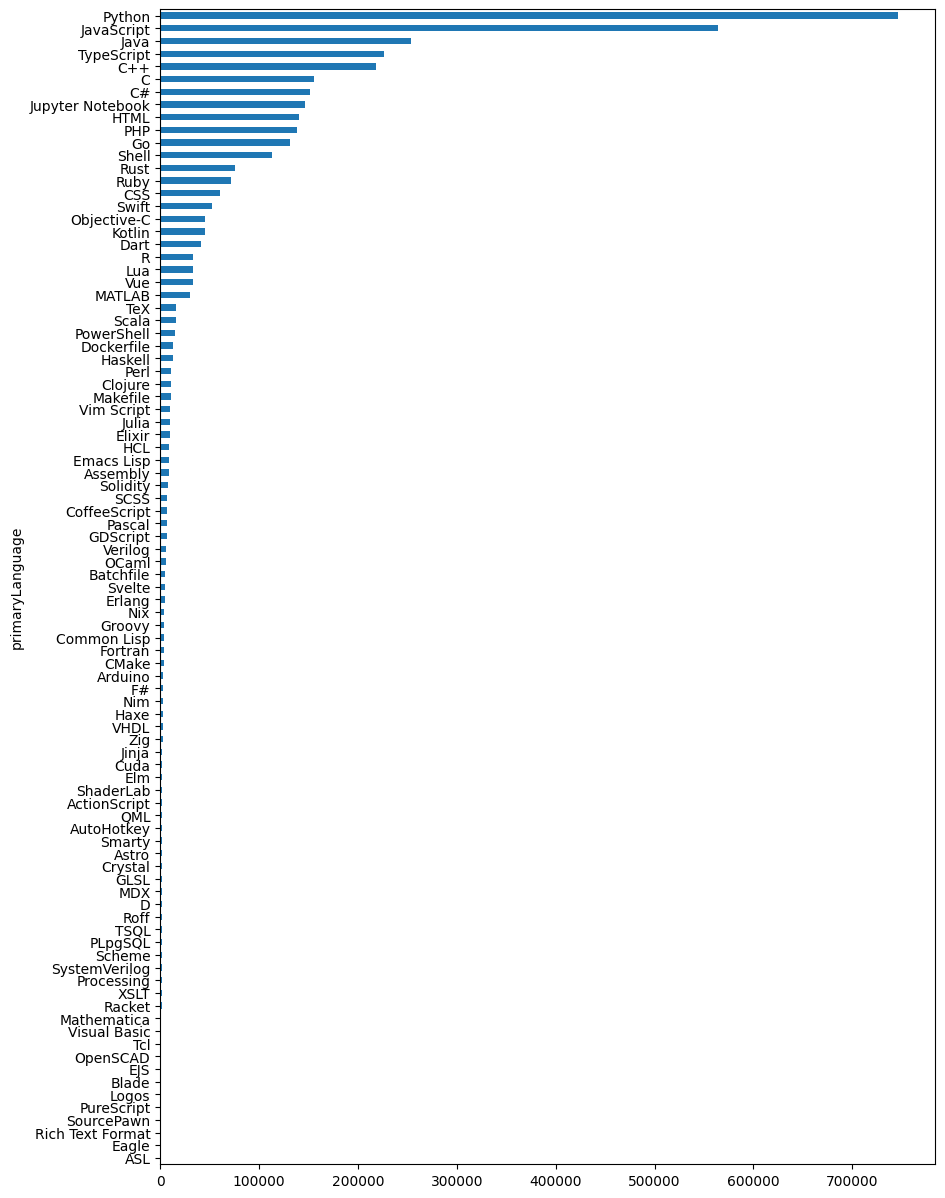

In [18]:
Repositeries_per_language_filtered.sort_values("repository_count", ascending=True).plot(kind='barh', figsize = (10, 15), legend = False)

In [19]:
# Seleccionant els llenguatges de programació
languages_selected = list(Repositeries_per_language_filtered.index)

df_interest = df_interest[df_interest["primaryLanguage"].isin(languages_selected)]

In [20]:
df_interest["license"].value_counts().describe()

count    4.700000e+01
mean     4.405064e+04
std      1.654503e+05
min      4.000000e+00
25%      1.135000e+02
50%      8.360000e+02
75%      1.045200e+04
max      1.079941e+06
Name: count, dtype: float64

<Axes: ylabel='license'>

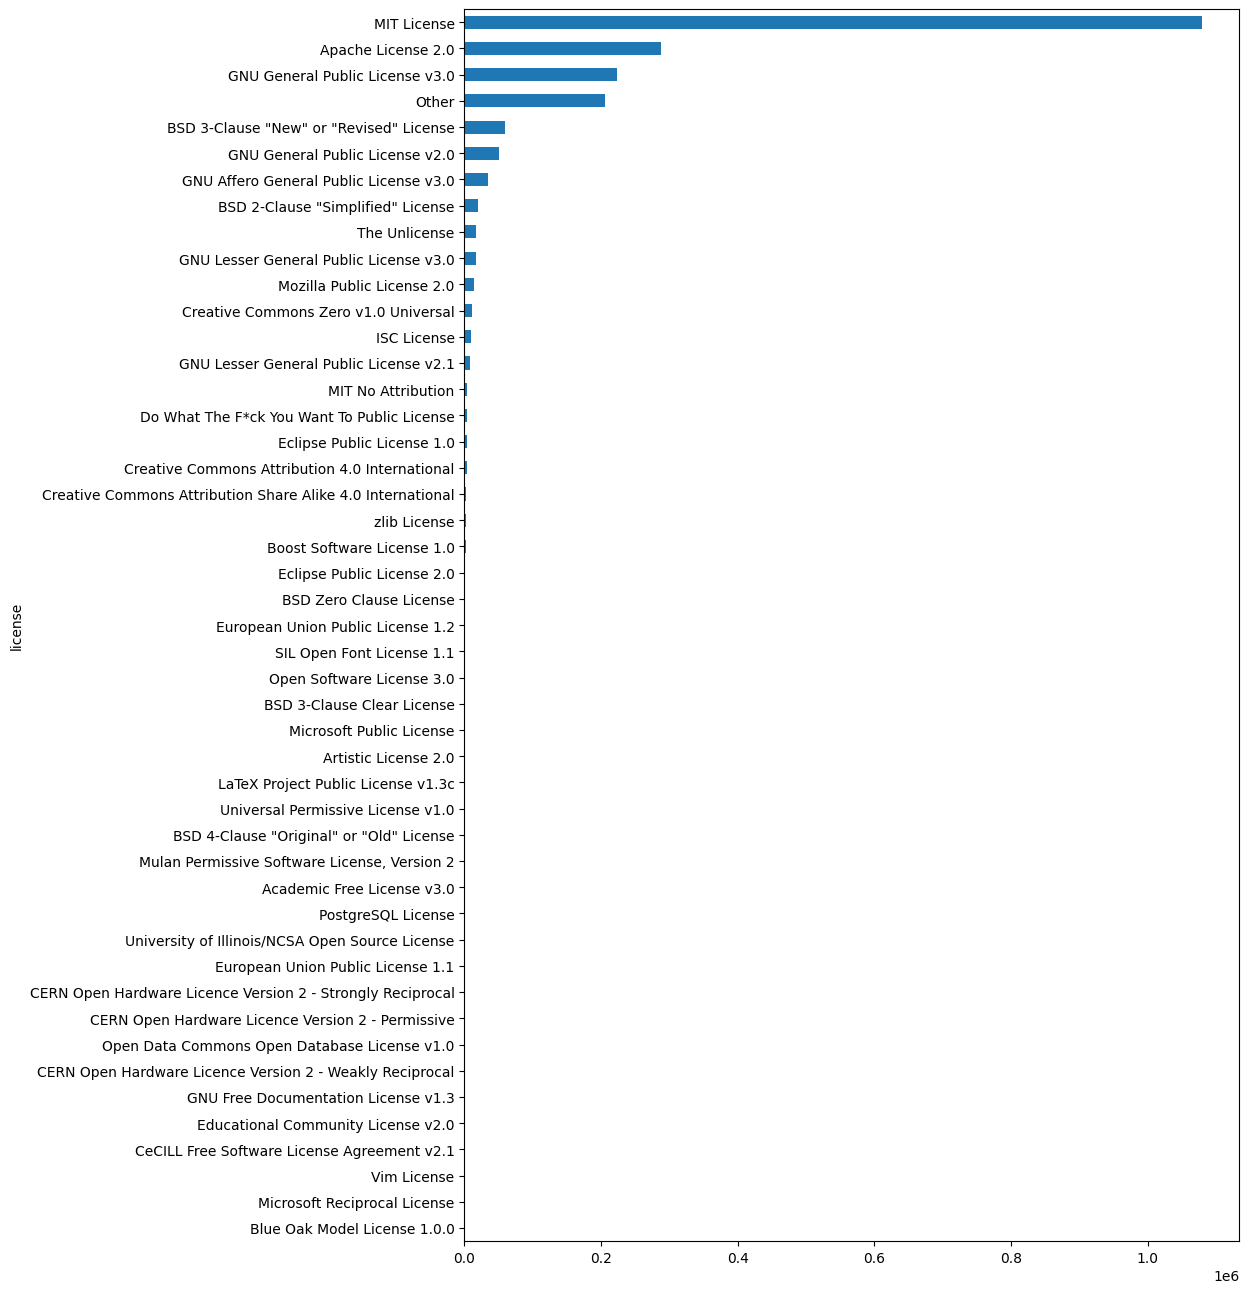

In [21]:
df_interest["license"].value_counts().sort_values().plot(kind="barh", figsize = (10, 16))

In [22]:
def get_topic_name(t):
    # retorna una llista de topics
    res = []
    for i in t:
        res.append(i["name"])

    return res

df_interest["topics_array"] = df_interest["topics"].apply(get_topic_name)

In [23]:
df_exploded = df_interest[["primaryLanguage","topics_array"]].explode("topics_array")

In [24]:
topic_counts = (
    df_exploded
    .groupby(["primaryLanguage", "topics_array"])
    .size()
    .reset_index(name="count")
)

In [25]:
topic_counts.sort_values("count", ascending=False)

,primaryLanguage,topics_array,count
876860,Python,python,65386
494014,JavaScript,javascript,32217
1164461,TypeScript,typescript,28347
280937,Go,golang,25258
404137,Java,java,25050
...,...,...,...
20,ASL,8250u,1
1198867,Zig,zksnark,1
1198866,Zig,zkg,1
1198865,Zig,zk,1


In [26]:
most_common_topic = (
    topic_counts
    .sort_values(["primaryLanguage", "count"], ascending=[True, False])
    .groupby("primaryLanguage")
    .head(10)
)

In [27]:
most_common_topic.to_csv("topics.csv")

In [28]:
most_common_topic.describe()

,count
count,910.000000
mean,1092.267033
std,3651.527485
min,4.000000
25%,36.000000
50%,122.000000
75%,612.000000
max,65386.000000


<Axes: title={'center': 'diskUsageKb'}, ylabel='primaryLanguage'>

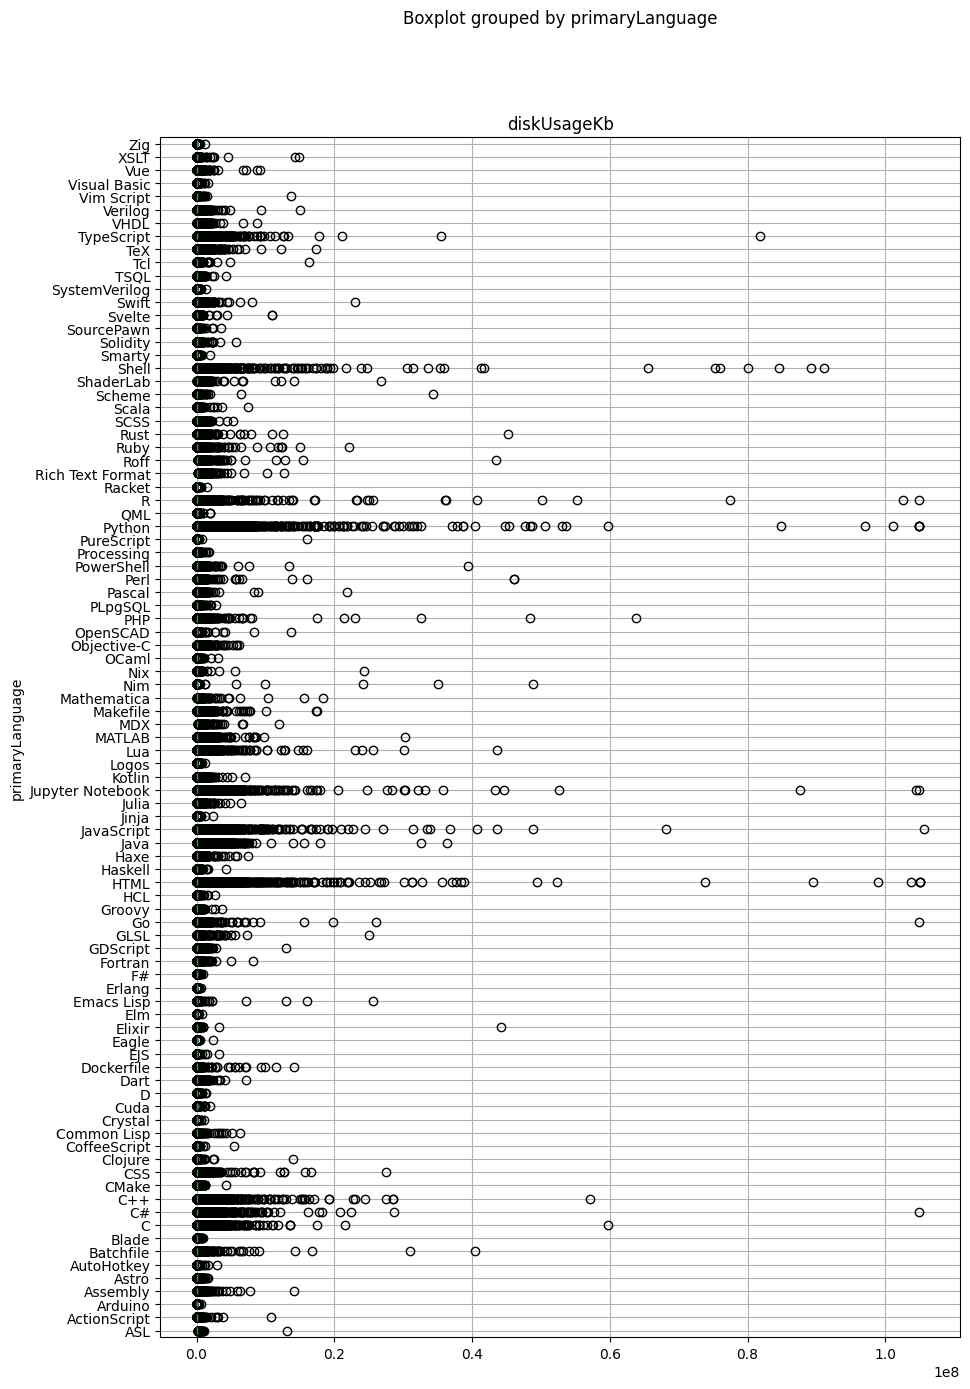

In [29]:
import matplotlib.pyplot as plt
df_interest.boxplot(column = ["diskUsageKb"], by = "primaryLanguage", vert = False, figsize=(10, 16))


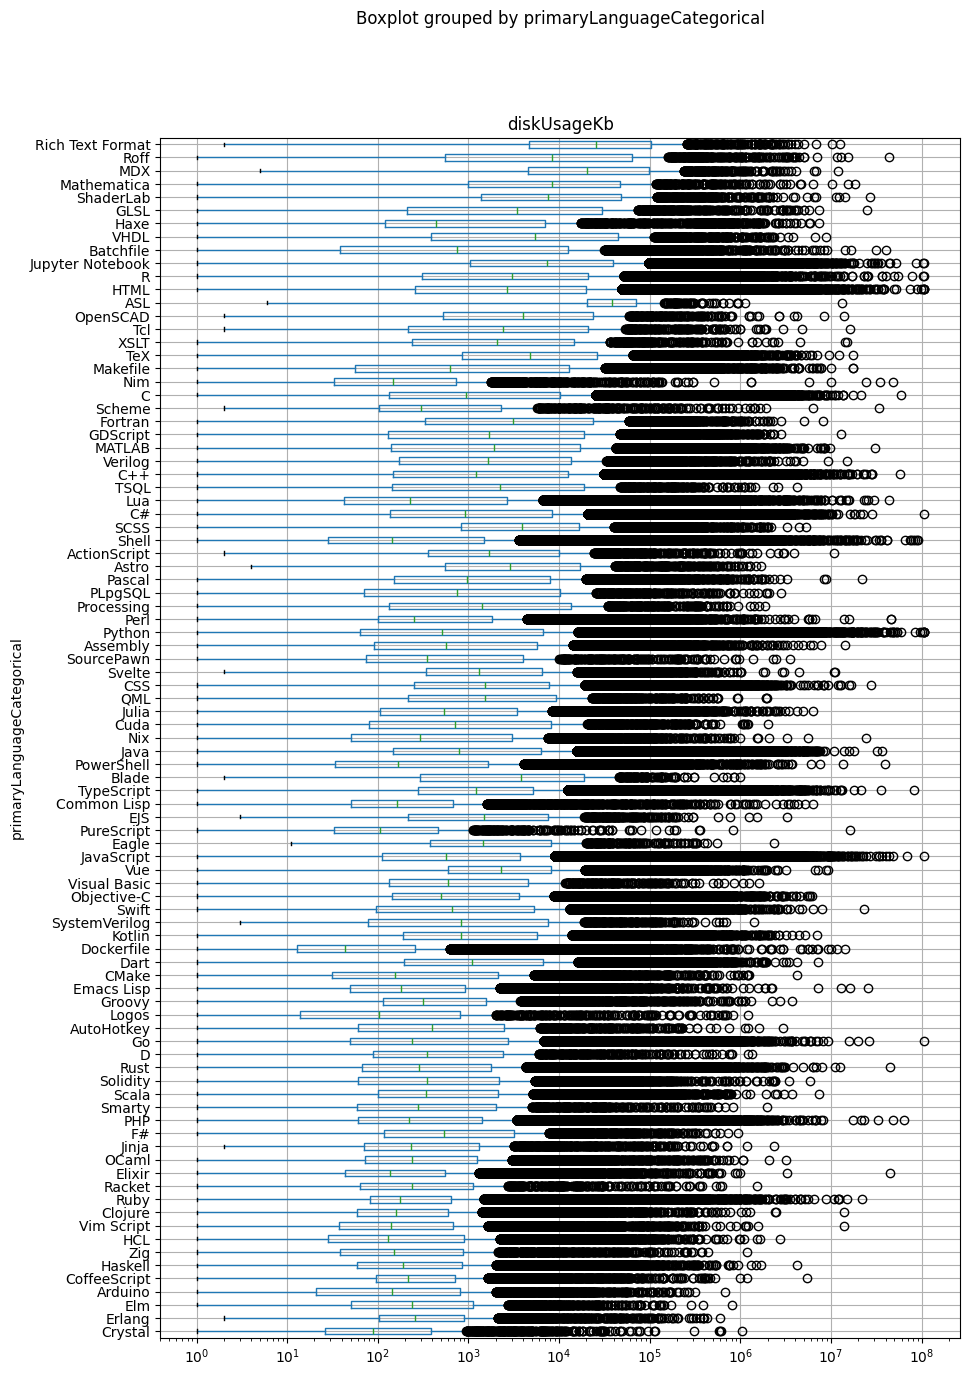

In [30]:
# Memoria en escala logaritmica per millorar la visualització
order = df_interest.groupby('primaryLanguage')['diskUsageKb'].mean().sort_values(ascending=True).index

df_interest['primaryLanguageCategorical'] = pd.Categorical(df_interest['primaryLanguage'], categories=order, ordered=True)

ax = df_interest.boxplot(column = "diskUsageKb", by = "primaryLanguageCategorical", vert = False, figsize=(10, 16))

ax.set_xscale('log')
plt.show()

In [31]:
for i in order:
    if i == "Javascript":
        print(i)

In [32]:
# Exportant a csv

df_interest.to_csv("preprocessed_dataset.csv")

In [33]:
Repositeries_per_language_filtered = Repositeries_per_language[Repositeries_per_language["repository_count"] > 3000]

In [34]:
Repositeries_per_language_filtered

,repository_count
primaryLanguage,
Python,746516
JavaScript,564674
Java,253601
TypeScript,226541
C++,218029
C,155556
C#,151763
Jupyter Notebook,146674
HTML,140448


In [35]:
Repositeries_per_language_filtered = Repositeries_per_language[Repositeries_per_language["repository_count"] > 1000]

languages_selected = list(Repositeries_per_language_filtered.index)

df_interest_two = df_interest[df_interest["primaryLanguage"].isin(languages_selected)]

In [36]:
df_interest_two = df_interest_two[df_interest_two["forks"] > 10][df_interest_two["watchers"] > 10][df_interest_two["pullRequests"] > 10][df_interest_two["issues"] > 10]

/tmp/ipykernel_55/3511087118.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_interest_two = df_interest_two[df_interest_two["forks"] > 10][df_interest_two["watchers"] > 10][df_interest_two["pullRequests"] > 10][df_interest_two["issues"] > 10]
/tmp/ipykernel_55/3511087118.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_interest_two = df_interest_two[df_interest_two["forks"] > 10][df_interest_two["watchers"] > 10][df_interest_two["pullRequests"] > 10][df_interest_two["issues"] > 10]
/tmp/ipykernel_55/3511087118.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_interest_two = df_interest_two[df_interest_two["forks"] > 10][df_interest_two["watchers"] > 10][df_interest_two["pullRequests"] > 10][df_interest_two["issues"] > 10]


<Axes: ylabel='primaryLanguage'>

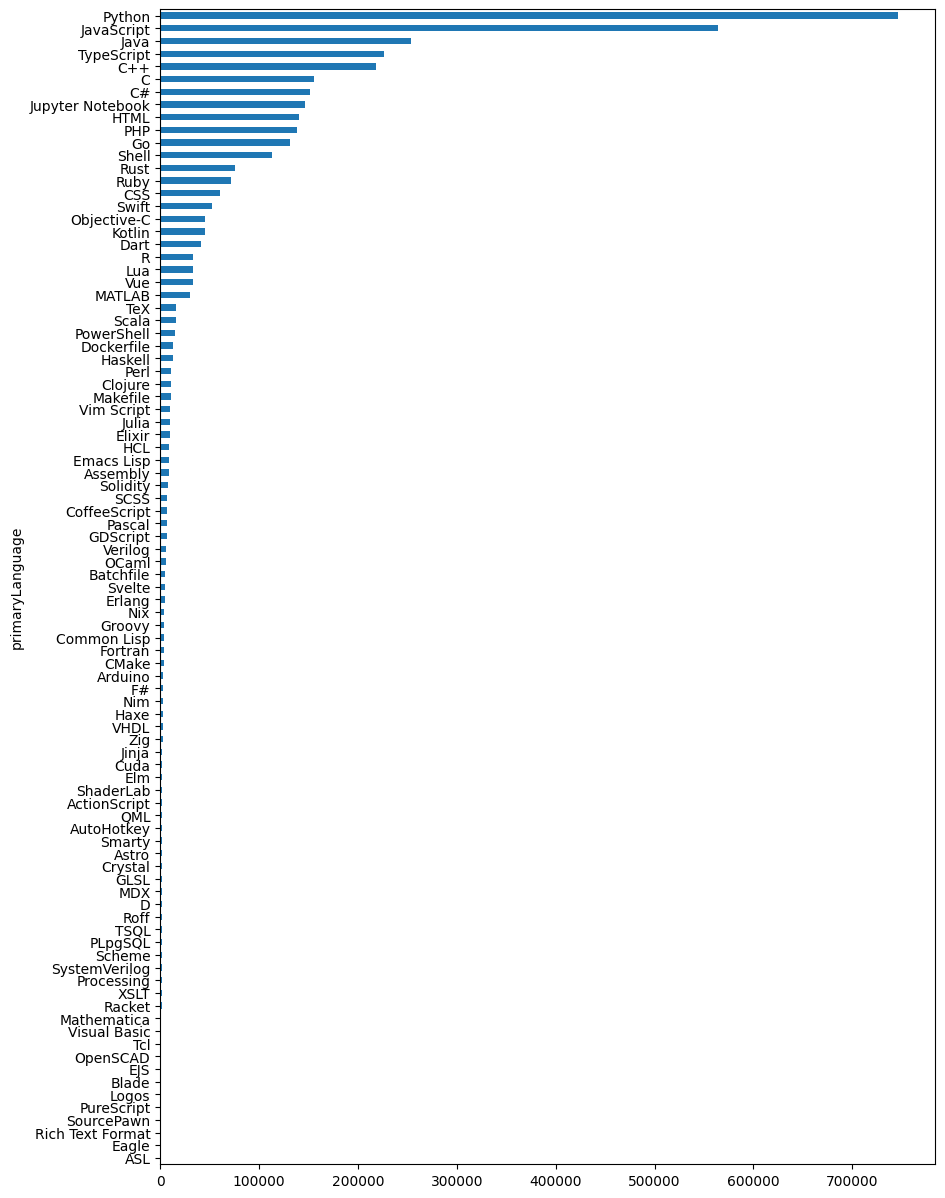

In [37]:
Repositeries_per_language_filtered.sort_values("repository_count", ascending=True).plot(kind='barh', figsize = (10, 15), legend = False)

In [38]:
df_interest_two

,nameWithOwner,primaryLanguage,diskUsageKb,stars,forks,watchers,pullRequests,issues,license,topics,createdAt,topics_array,primaryLanguageCategorical
0,freeCodeCamp/freeCodeCamp,TypeScript,512574,426893,41377,8588,41267,19849,"BSD 3-Clause ""New"" or ""Revised"" License","[{'name': 'learn-to-code', 'stars': 480}, {'na...",2014-12-24T17:49:19Z,"[learn-to-code, nonprofits, programming, nodej...",TypeScript
3,EbookFoundation/free-programming-books,Python,19611,366964,64025,9879,10495,1184,Creative Commons Attribution 4.0 International,"[{'name': 'education', 'stars': 684}, {'name':...",2013-10-11T06:50:37Z,"[education, books, list, resource, hacktoberfest]",Python
4,public-apis/public-apis,Python,4771,363505,38166,4360,3571,718,MIT License,"[{'name': 'api', 'stars': 105389}, {'name': 'p...",2016-03-20T23:49:42Z,"[api, public-apis, free, apis, list, developme...",Python
5,kamranahmedse/developer-roadmap,TypeScript,309896,335089,42672,6862,5398,2946,Other,"[{'name': 'computer-science', 'stars': 676}, {...",2017-03-15T13:45:52Z,"[computer-science, roadmap, developer-roadmap,...",TypeScript
7,donnemartin/system-design-primer,Python,11239,318206,52053,6792,603,341,Other,"[{'name': 'programming', 'stars': 1849}, {'nam...",2017-02-26T16:15:28Z,"[programming, development, design, design-syst...",Python
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4208086,sustainable-computing-io/local-dev-cluster,Shell,133,5,15,13,76,31,Apache License 2.0,[],2023-01-25T13:34:22Z,[],Shell
4209481,project-codeflare/codeflare-operator,Go,1383,5,66,12,551,147,Apache License 2.0,[],2023-01-31T19:59:21Z,[],Go
4210110,Kong/public-shared-actions,Shell,490,5,14,78,291,12,MIT License,[],2023-02-03T17:15:41Z,[],Shell
4229646,podman-desktop/e2e,Go,4052,5,11,14,197,260,Apache License 2.0,[],2023-05-23T14:22:18Z,[],Go


In [39]:
df_interest_two.to_csv("preprocessed_dataset_redux.csv")

<Axes: ylabel='license'>

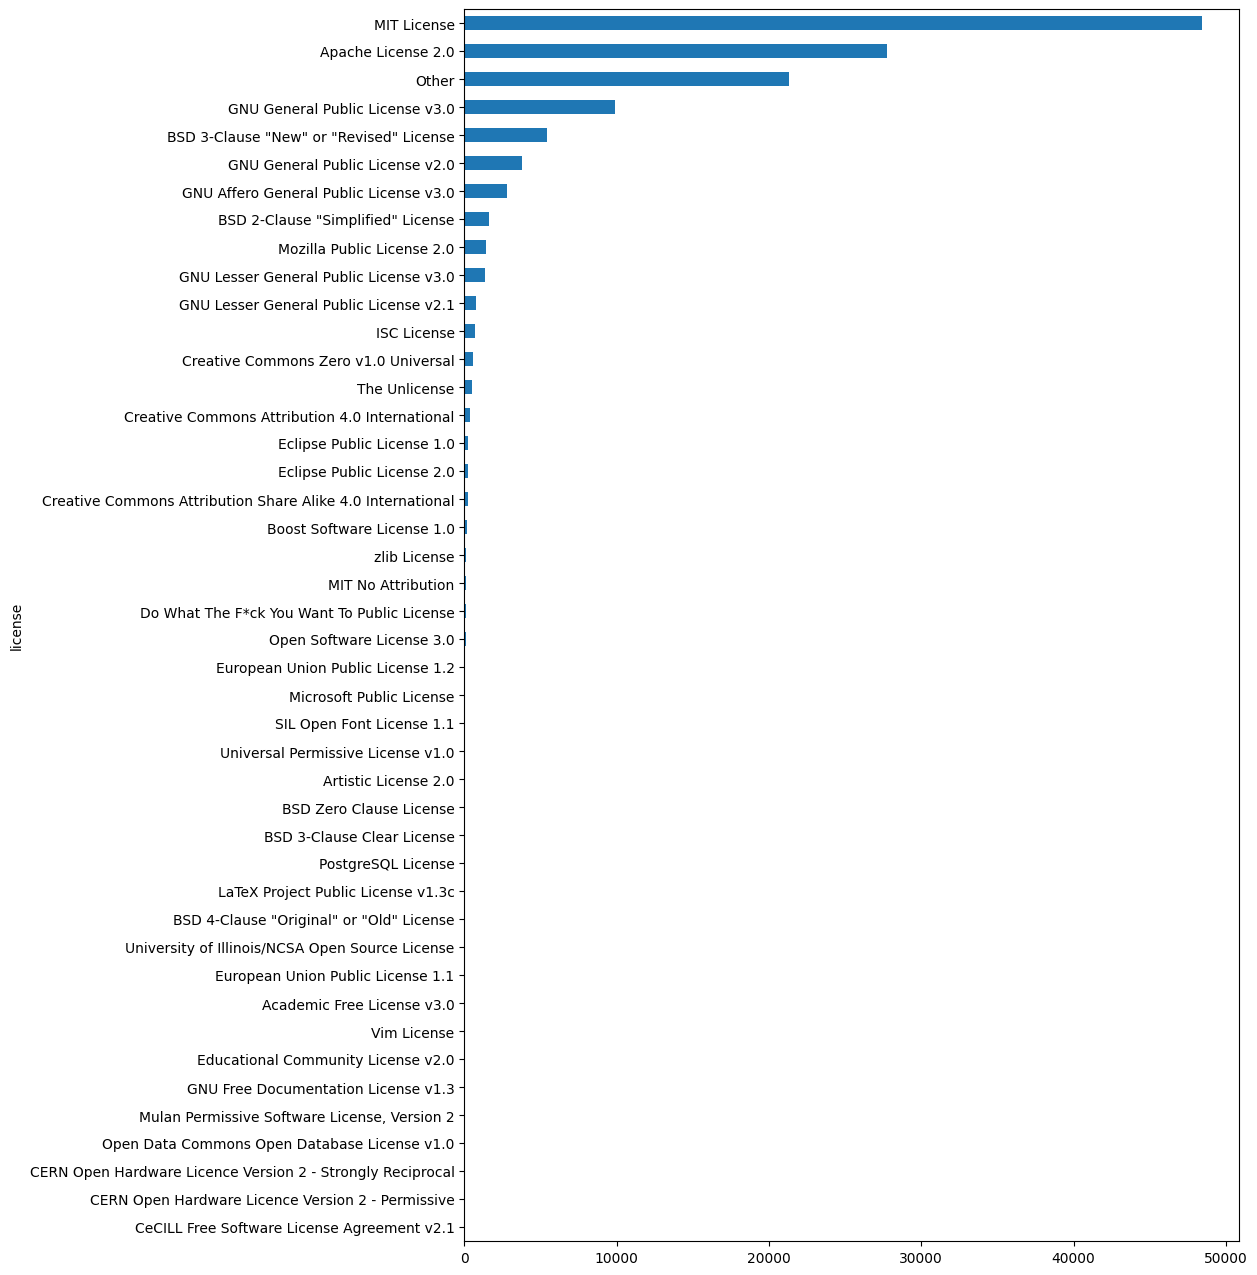

In [40]:
df_interest_two["license"].value_counts().sort_values().plot(kind="barh", figsize = (10, 16))